# 03 — EDA Survey

**Fingo Income Predictor** | Tim CC26-PSU217

Input:
- `data/processed/survey_temporal_mapped.csv`
- `data/processed/survey_weekly_income_long.csv`

Output:
- Chart ke `outputs/charts/`
- Dashboard CSV ke `outputs/dashboard/`
- `outputs/reports/survey_eda_summary.md`

In [1]:
# GIT PULL — Sinkronisasi terbaru dari remote sebelum mulai
import os, shutil, subprocess

try:
    from google.colab import userdata
except Exception:
    userdata = None

os.chdir("/content")

GITHUB_USERNAME = "ClarisyaA"
REPO_NAME       = "fingo-income-analysis"
BRANCH_NAME     = "feat/income-predictor-final"
LOCAL_DIR       = f"/content/{REPO_NAME}"
FRESH_CLONE     = False  # Set True hanya kalau mau clone ulang dari nol

def get_remote_url():
    try:
        token = userdata.get("GITHUB_TOKEN") if userdata else os.environ.get("GITHUB_TOKEN", "")
        if token:
            return f"https://{token}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git", token
    except Exception:
        pass
    return f"https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git", None

remote_url, token = get_remote_url()

def mask_cmd(cmd):
    return cmd.replace(token, "***TOKEN***") if token else cmd

def run_cmd(cmd, check=True, cwd="/content"):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=cwd)
    print(f"$ {mask_cmd(cmd)}")
    if r.stdout.strip(): print(r.stdout.strip())
    if r.stderr.strip(): print(r.stderr.strip())
    if check and r.returncode != 0:
        raise RuntimeError(f"Command gagal: {mask_cmd(cmd)}")
    return r

def remote_branch_exists():
    r = run_cmd(f"git ls-remote --heads {remote_url} {BRANCH_NAME}", check=False)
    return r.stdout.strip() != ""

branch_exists = remote_branch_exists()

if FRESH_CLONE and os.path.exists(LOCAL_DIR):
    os.chdir("/content")
    shutil.rmtree(LOCAL_DIR)

if not os.path.exists(LOCAL_DIR):
    if branch_exists:
        run_cmd(f"git clone -b {BRANCH_NAME} {remote_url} {LOCAL_DIR}")
    else:
        run_cmd(f"git clone {remote_url} {LOCAL_DIR}")
        run_cmd(f"git checkout -b {BRANCH_NAME}", cwd=LOCAL_DIR)
else:
    run_cmd(f"git remote set-url origin {remote_url}", cwd=LOCAL_DIR)
    run_cmd("git fetch origin", cwd=LOCAL_DIR)

    if branch_exists:
        local_b = run_cmd(f"git branch --list {BRANCH_NAME}", check=False, cwd=LOCAL_DIR).stdout.strip()
        if local_b:
            run_cmd(f"git checkout {BRANCH_NAME}", cwd=LOCAL_DIR)
        else:
            run_cmd(f"git checkout -b {BRANCH_NAME} origin/{BRANCH_NAME}", cwd=LOCAL_DIR)
        run_cmd(f"git pull --rebase origin {BRANCH_NAME}", cwd=LOCAL_DIR)
    else:
        current = run_cmd("git branch --show-current", check=False, cwd=LOCAL_DIR).stdout.strip()
        if current != BRANCH_NAME:
            local_b = run_cmd(f"git branch --list {BRANCH_NAME}", check=False, cwd=LOCAL_DIR).stdout.strip()
            if local_b:
                run_cmd(f"git checkout {BRANCH_NAME}", cwd=LOCAL_DIR)
            else:
                run_cmd(f"git checkout -b {BRANCH_NAME}", cwd=LOCAL_DIR)

os.chdir(LOCAL_DIR)
run_cmd(f"git remote set-url origin {remote_url}", cwd=LOCAL_DIR)
print("\n✓ Repo siap digunakan")
print(f"✓ Working directory: {os.getcwd()}")
run_cmd("git branch --show-current", cwd=LOCAL_DIR)
run_cmd("git status --short", check=False, cwd=LOCAL_DIR)

$ git ls-remote --heads https://***TOKEN***@github.com/ClarisyaA/fingo-income-analysis.git feat/income-predictor-final
250635a74ac2099c178baa7ff59a713b9aa8788c	refs/heads/feat/income-predictor-final
$ git clone -b feat/income-predictor-final https://***TOKEN***@github.com/ClarisyaA/fingo-income-analysis.git /content/fingo-income-analysis
Cloning into '/content/fingo-income-analysis'...
$ git remote set-url origin https://***TOKEN***@github.com/ClarisyaA/fingo-income-analysis.git

✓ Repo siap digunakan
✓ Working directory: /content/fingo-income-analysis
$ git branch --show-current
feat/income-predictor-final
$ git status --short


CompletedProcess(args='git status --short', returncode=0, stdout='', stderr='')

In [2]:
import os, json, warnings, re, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="Set2")
except Exception:
    sns = None

warnings.filterwarnings("ignore")
os.chdir("/content/fingo-income-analysis")

IDR_FMT = mticker.FuncFormatter(lambda x, _: f"Rp {x/1e6:.1f}jt" if x >= 1e6 else f"Rp {x/1e3:.0f}rb")

def fmt_idr(val):
    if pd.isna(val): return "NaN"
    if val >= 1_000_000: return f"Rp {val/1_000_000:.2f}jt"
    return f"Rp {val/1_000:.0f}rb"

def ensure_dir(path):
    d = os.path.dirname(path) if "." in os.path.basename(path) else path
    if d: os.makedirs(d, exist_ok=True)

def safe_to_csv(df, path, **kwargs):
    ensure_dir(path)
    df.to_csv(path, index=kwargs.pop("index", False), **kwargs)
    return True

def safe_savefig(path, **kwargs):
    ensure_dir(path)
    plt.savefig(path, dpi=kwargs.pop("dpi", 150), bbox_inches="tight", **kwargs)

def safe_read_csv(path, **kwargs):
    for sep in [",", ";", "\t"]:
        try:
            df = pd.read_csv(path, sep=sep, **kwargs)
            if len(df.columns) > 1:
                return df
        except Exception:
            continue
    warnings.warn(f"[WARN] Gagal membaca {path}")
    return pd.DataFrame()

def find_file_by_keywords(folder, keywords):
    if not os.path.isdir(folder): return None
    for fname in os.listdir(folder):
        if all(kw.lower() in fname.lower() for kw in keywords):
            return os.path.join(folder, fname)
    return None

def get_week_of_month(date):
    """
    Week 1 = tanggal 1–7
    Week 2 = tanggal 8–14
    Week 3 = tanggal 15–21
    Week 4 = tanggal 22–28
    Week 5 = tanggal 29–31
    """
    if pd.isna(date): return np.nan
    return int((date.day - 1) // 7 + 1)

print("✓ Setup selesai")

ORDERED_GIG_TYPES = ["ojek_online", "kurir", "jualan_online", "freelance_desain",
                     "freelance_it", "content_creator", "tutor", "pekerja_harian"]

✓ Setup selesai


In [3]:
# CELL 03.3 — Load data
df = pd.read_csv("data/processed/survey_temporal_mapped.csv")
df_long = pd.read_csv("data/processed/survey_weekly_income_long.csv")

if "timestamp_parsed" in df.columns:
    df["timestamp_parsed"] = pd.to_datetime(df["timestamp_parsed"], errors="coerce")

for dcol in ["period_start", "period_end"]:
    if dcol in df_long.columns:
        df_long[dcol] = pd.to_datetime(df_long[dcol], errors="coerce")

print(f"✓ survey_temporal_mapped: {df.shape}")
print(f"✓ survey_weekly_income_long: {df_long.shape}")
print(f"  Unique respondents long: {df_long['respondent_id'].nunique()}")

✓ survey_temporal_mapped: (384, 86)
✓ survey_weekly_income_long: (1536, 12)
  Unique respondents long: 384


## EDA — Distribusi Gig Type & Domisili

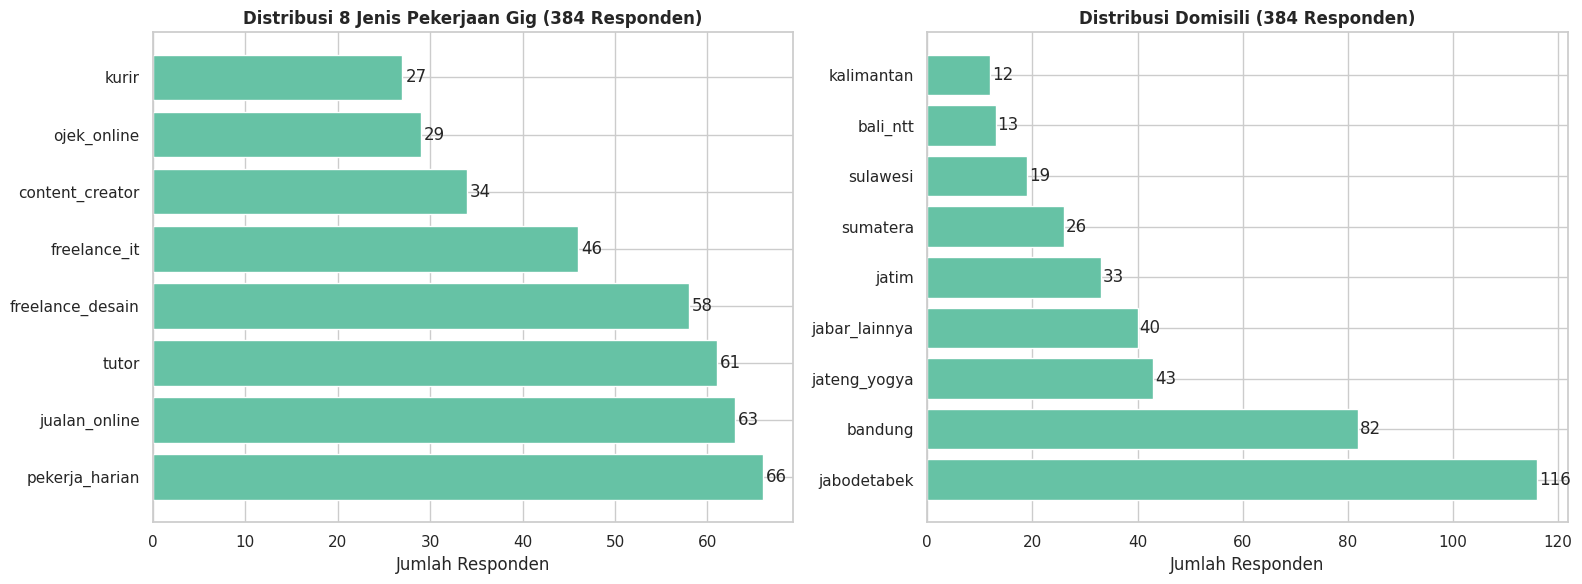

True

In [4]:
# CELL 03.4 — Distribusi gig_type dan domisili
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

gig_counts = df["gig_type"].value_counts()
axes[0].barh(gig_counts.index, gig_counts.values)
axes[0].set_title("Distribusi 8 Jenis Pekerjaan Gig (384 Responden)", fontweight="bold")
axes[0].set_xlabel("Jumlah Responden")
for i, v in enumerate(gig_counts.values):
    axes[0].text(v + 0.3, i, str(v), va="center")

dom_counts = df["domisili_code"].value_counts()
axes[1].barh(dom_counts.index, dom_counts.values)
axes[1].set_title("Distribusi Domisili (384 Responden)", fontweight="bold")
axes[1].set_xlabel("Jumlah Responden")
for i, v in enumerate(dom_counts.values):
    axes[1].text(v + 0.3, i, str(v), va="center")

plt.tight_layout()
safe_savefig("outputs/charts/gig_type_distribution.png")
plt.show()
safe_to_csv(gig_counts.reset_index().rename(columns={"count":"n"}), "outputs/dashboard/gig_type_distribution.csv")

## EDA — Income per Gig Type

=== Income Summary per Gig Type ===
        gig_type  n  avg_weekly  median_weekly  std_weekly    cv  avg_monthly
 content_creator 34    376961.0       298333.0    268475.0 0.134    1403676.0
freelance_desain 58    590453.0       532292.0    383663.0 0.134    2238448.0
    freelance_it 46    790018.0       682500.0    483436.0 0.130    2958804.0
   jualan_online 63    339325.0       315000.0    181672.0 0.129    1271190.0
           kurir 27    388753.0       385500.0     62509.0 0.187    1496556.0
     ojek_online 29    382382.0       366250.0    142748.0 0.147    1484931.0
  pekerja_harian 66    428125.0       392083.0    234103.0 0.131    1573864.0
           tutor 61    461954.0       382500.0    310884.0 0.141    1715492.0


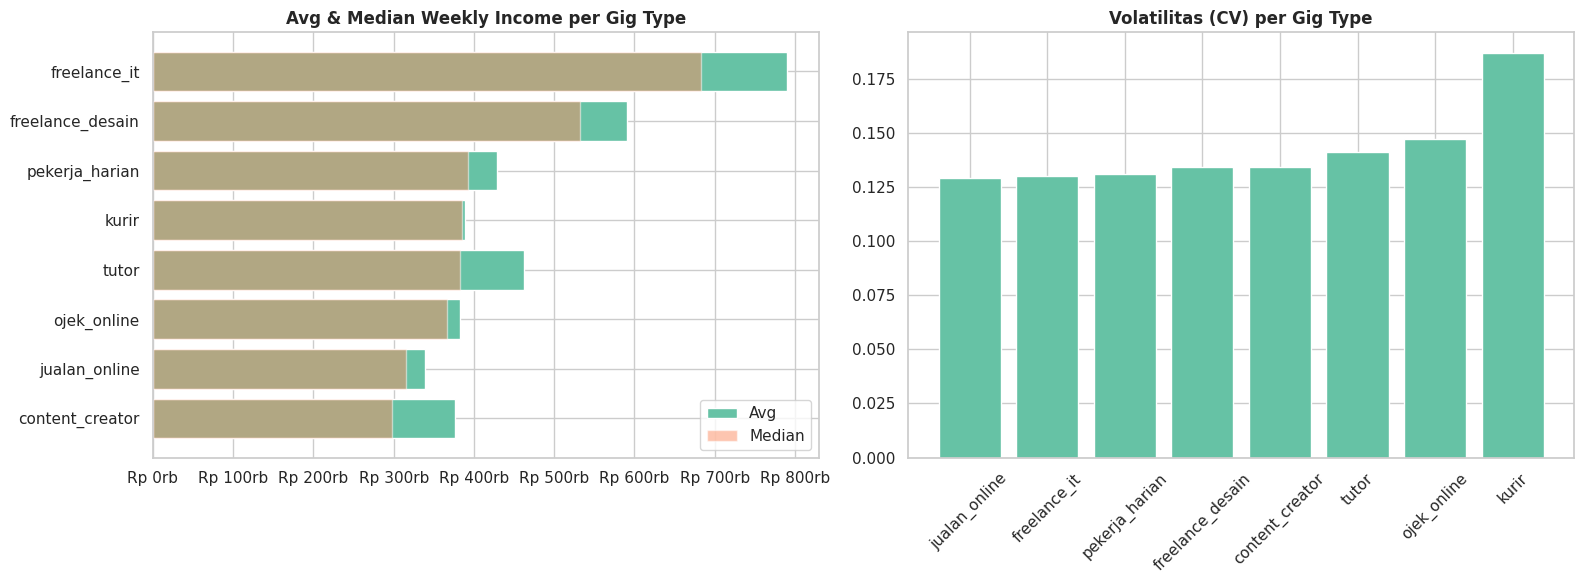

True

In [5]:
# CELL 03.5 — Income summary per gig_type
gig_income_summary = df.groupby("gig_type").agg(
    n=("respondent_id", "count"),
    avg_weekly=("avg_weekly_income", "mean"),
    median_weekly=("avg_weekly_income", "median"),
    std_weekly=("avg_weekly_income", "std"),
    cv=("income_cv_4w", "mean"),
    avg_monthly=("monthly_income", "mean"),
).reset_index()

for c in ["avg_weekly", "median_weekly", "std_weekly", "avg_monthly"]:
    gig_income_summary[c] = gig_income_summary[c].round(0)
gig_income_summary["cv"] = gig_income_summary["cv"].round(3)

print("=== Income Summary per Gig Type ===")
print(gig_income_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sorted_df = gig_income_summary.sort_values("median_weekly")
axes[0].barh(sorted_df["gig_type"], sorted_df["avg_weekly"], label="Avg")
axes[0].barh(sorted_df["gig_type"], sorted_df["median_weekly"], alpha=0.5, label="Median")
axes[0].set_title("Avg & Median Weekly Income per Gig Type", fontweight="bold")
axes[0].xaxis.set_major_formatter(IDR_FMT)
axes[0].legend()

cv_sorted = gig_income_summary.sort_values("cv")
axes[1].bar(cv_sorted["gig_type"], cv_sorted["cv"])
axes[1].set_title("Volatilitas (CV) per Gig Type", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
safe_savefig("outputs/charts/income_by_gig_type.png")
plt.show()
safe_to_csv(gig_income_summary, "outputs/dashboard/real_4w_income_summary.csv")

## EDA — Temporal: Relative Week, Calendar Month, Week of Month

=== Income per Relative Week ===
                   mean    median       std
relative_week                              
W4 (terlama)   447318.0  365000.0  350185.0
W3             443237.0  352500.0  333425.0
W2             455836.0  387500.0  344122.0
W1 (terbaru)   439378.0  355000.0  338448.0


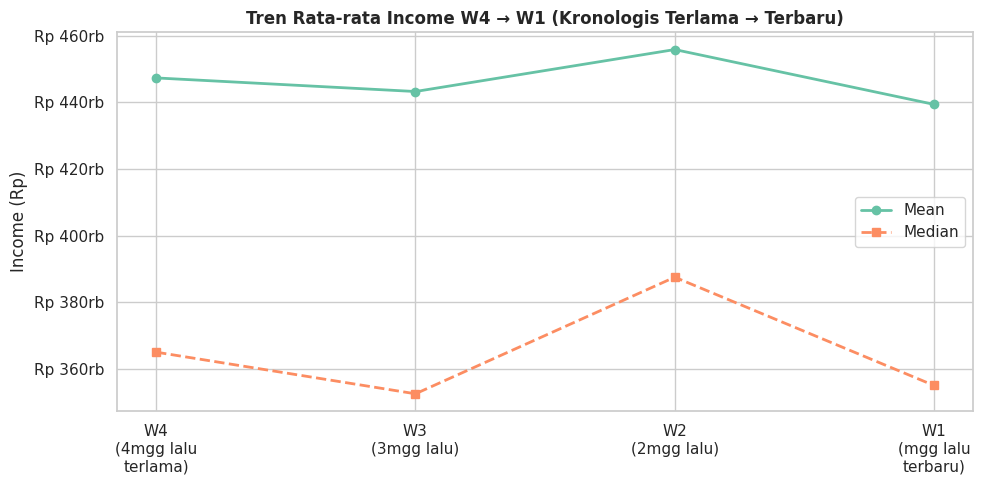

In [6]:
# CELL 03.6 — Analisis relative_week (W4 terlama → W1 terbaru)
rw_summary = df_long.groupby("relative_week")["weekly_income"].agg(["mean","median","std"]).round(0)
rw_summary.index = rw_summary.index.map({-4:"W4 (terlama)",-3:"W3",-2:"W2",-1:"W1 (terbaru)"})
print("=== Income per Relative Week ===")
print(rw_summary.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
labels = ["W4\n(4mgg lalu\nterlama)", "W3\n(3mgg lalu)", "W2\n(2mgg lalu)", "W1\n(mgg lalu\nterbaru)"]
week_means   = [df[f"income_w{w}"].mean()   for w in [4, 3, 2, 1]]
week_medians = [df[f"income_w{w}"].median() for w in [4, 3, 2, 1]]
ax.plot(labels, week_means,   "o-", label="Mean",   linewidth=2)
ax.plot(labels, week_medians, "s--", label="Median", linewidth=2)
ax.set_title("Tren Rata-rata Income W4 → W1 (Kronologis Terlama → Terbaru)", fontweight="bold")
ax.set_ylabel("Income (Rp)")
ax.yaxis.set_major_formatter(IDR_FMT)
ax.legend()
plt.tight_layout()
safe_savefig("outputs/charts/weekly_income_trend_w4_to_w1.png")
plt.show()

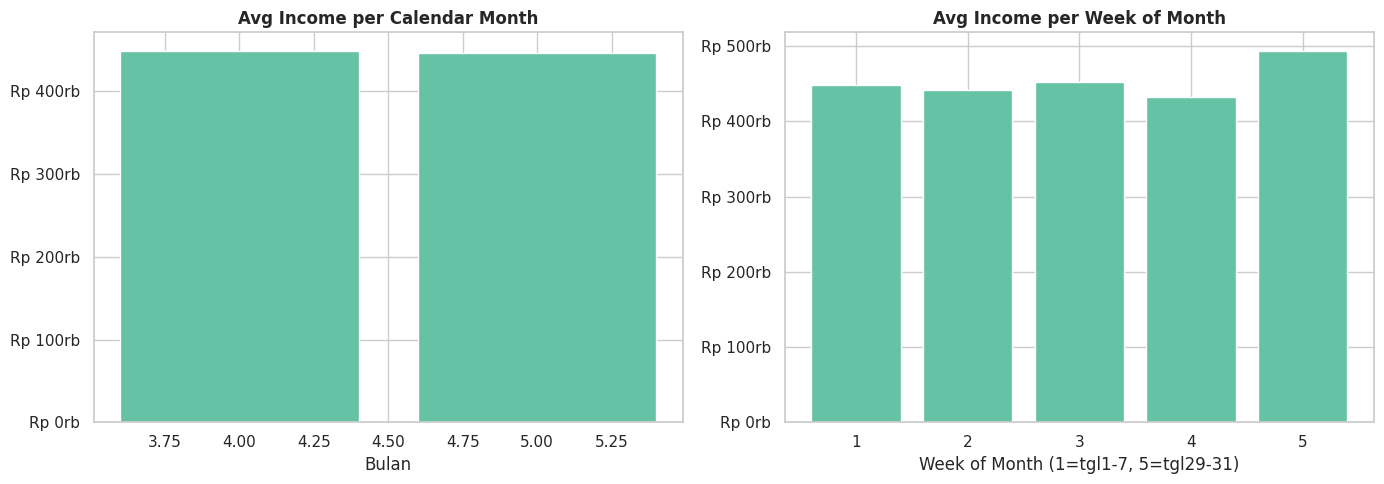

Income tertinggi di week_of_month: 5
Income tertinggi di relative_week: -2


In [7]:
# CELL 03.7 — Analisis calendar_month dan week_of_month
df_long_clean = df_long.dropna(subset=["calendar_month", "week_of_month"]).copy()
df_long_clean["calendar_month"] = df_long_clean["calendar_month"].astype(int)
df_long_clean["week_of_month"]  = df_long_clean["week_of_month"].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_mean = df_long_clean.groupby("calendar_month")["weekly_income"].mean()
axes[0].bar(cm_mean.index, cm_mean.values)
axes[0].set_title("Avg Income per Calendar Month", fontweight="bold")
axes[0].set_xlabel("Bulan")
axes[0].yaxis.set_major_formatter(IDR_FMT)

wom_mean = df_long_clean.groupby("week_of_month")["weekly_income"].mean()
axes[1].bar(wom_mean.index, wom_mean.values)
axes[1].set_title("Avg Income per Week of Month", fontweight="bold")
axes[1].set_xlabel("Week of Month (1=tgl1-7, 5=tgl29-31)")
axes[1].yaxis.set_major_formatter(IDR_FMT)

plt.tight_layout()
safe_savefig("outputs/charts/eda_calendar_month_wom.png")
plt.show()

peak_wom = wom_mean.idxmax()
peak_rw  = df_long.groupby("relative_week")["weekly_income"].mean().idxmax()
print(f"Income tertinggi di week_of_month: {peak_wom}")
print(f"Income tertinggi di relative_week: {peak_rw}")

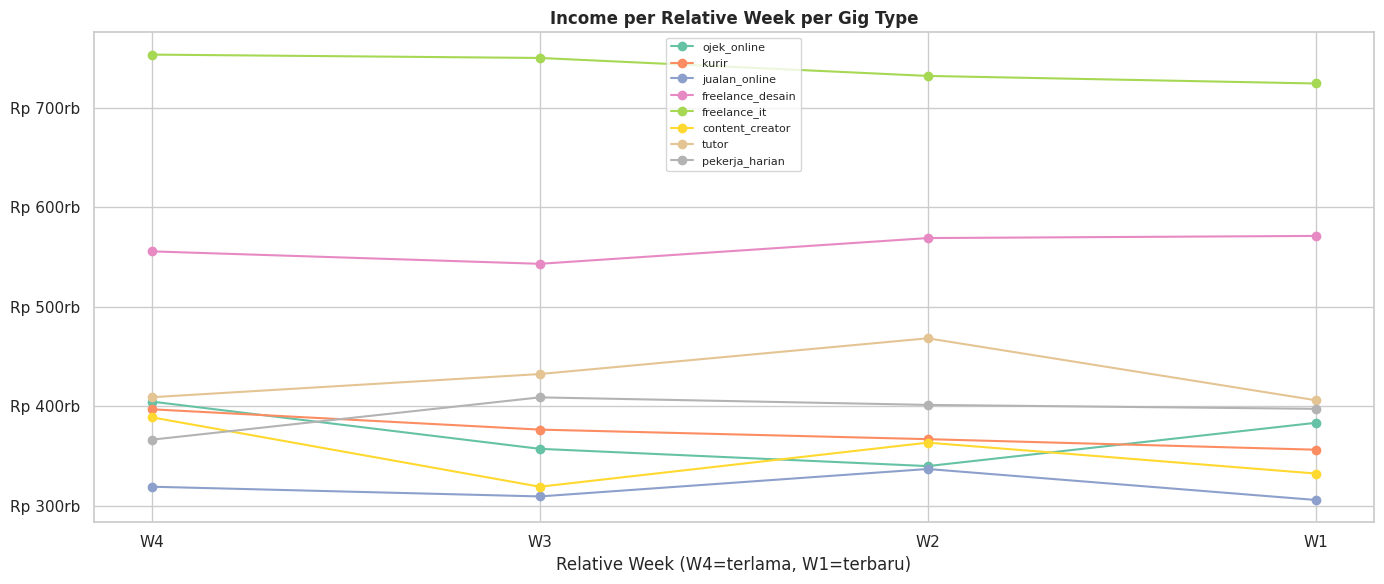

In [8]:
# CELL 03.8 — Analisis per gig_type × relative_week
fig, ax = plt.subplots(figsize=(14, 6))
for gt in ORDERED_GIG_TYPES:
    sub = df_long[df_long["gig_type"] == gt].groupby("relative_week")["weekly_income"].mean()
    if len(sub) == 0:
        continue
    labels = [f"W{abs(rw)}" for rw in sorted(sub.index)]
    ax.plot(labels, [sub[rw] for rw in sorted(sub.index)], "o-", label=gt, linewidth=1.5)

ax.set_title("Income per Relative Week per Gig Type", fontweight="bold")
ax.set_xlabel("Relative Week (W4=terlama, W1=terbaru)")
ax.yaxis.set_major_formatter(IDR_FMT)
ax.legend(fontsize=8)
plt.tight_layout()
safe_savefig("outputs/charts/eda_income_rw_by_gig.png")
plt.show()

In [9]:
# CELL 03.9 — Simpan EDA summary
ensure_dir("outputs/reports/")

insight_lines = []
rw_mean = df_long.groupby("relative_week")["weekly_income"].mean()
wom_mean = df_long.dropna(subset=["week_of_month"]).groupby("week_of_month")["weekly_income"].mean()
cm_mean  = df_long.dropna(subset=["calendar_month"]).groupby("calendar_month")["weekly_income"].mean()

insight_lines.append("# Survey EDA Summary — Fingo Income Predictor\n")
insight_lines.append("## Relative Week (W4=terlama, W1=terbaru)")
for rw in [-4,-3,-2,-1]:
    insight_lines.append(f"- W{abs(rw)}: mean={fmt_idr(rw_mean.get(rw,0))}")
insight_lines.append(f"\n**Income tertinggi di relative_week: W{abs(rw_mean.idxmax())}**")

insight_lines.append("\n## Week of Month (1=tgl1-7, ..., 5=tgl29-31)")
for w, v in wom_mean.items():
    insight_lines.append(f"- Week {int(w)}: mean={fmt_idr(v)}")
insight_lines.append(f"\n**Income tertinggi di week_of_month: {int(wom_mean.idxmax())}**")

insight_lines.append("\n## Calendar Month")
for m, v in cm_mean.items():
    insight_lines.append(f"- Bulan {int(m)}: mean={fmt_idr(v)}")

insight_lines.append("\n## Pola per Gig Type")
for gt in ORDERED_GIG_TYPES:
    sub_rw = df_long[df_long["gig_type"]==gt].groupby("relative_week")["weekly_income"].mean()
    if len(sub_rw):
        insight_lines.append(f"- {gt}: peak relative_week = W{abs(sub_rw.idxmax())}")

with open("outputs/reports/survey_eda_summary.md", "w", encoding="utf-8") as f:
    f.write("\n".join(insight_lines))

print("✓ Disimpan: outputs/reports/survey_eda_summary.md")

✓ Disimpan: outputs/reports/survey_eda_summary.md


In [10]:
# GIT PUSH — Commit dan push output notebook ini ke GitHub
import os, subprocess

LOCAL_DIR   = "/content/fingo-income-analysis"
BRANCH_NAME = "feat/income-predictor-final"
NOTEBOOK_NAME = "03_EDA_Survey.ipynb"

os.chdir(LOCAL_DIR)

def run_cmd(cmd, check=True):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(f"$ {cmd}")
    if r.stdout.strip(): print(r.stdout.strip())
    if r.stderr.strip(): print(r.stderr.strip())
    if check and r.returncode != 0:
        raise RuntimeError(f"Command gagal: {cmd}")
    return r

run_cmd('git config user.email "adelineclarisya@gmail.com"')
run_cmd('git config user.name "ClarisyaA"')

print("\n[1] Cek status")
run_cmd("git status --short", check=False)

print("\n[2] Add semua perubahan output")
run_cmd("git add data/ outputs/ notebooks/ *.ipynb", check=False)

print("\n[3] Commit")
commit_result = run_cmd(
    f'git commit -m "feat(DS2): output dari {NOTEBOOK_NAME}"',
    check=False
)
if commit_result.returncode != 0:
    print("[INFO] Tidak ada perubahan baru, skip commit.")

print("\n[4] Fetch remote terbaru")
run_cmd("git fetch origin")

print("\n[5] Rebase lalu push")
run_cmd(f"git pull --rebase origin {BRANCH_NAME}", check=False)
run_cmd(f"git push -u origin {BRANCH_NAME}")

print("\n✓ Push berhasil!")

$ git config user.email "adelineclarisya@gmail.com"
$ git config user.name "ClarisyaA"

[1] Cek status
$ git status --short
M outputs/charts/gig_type_distribution.png
 M outputs/charts/income_by_gig_type.png
 M outputs/charts/weekly_income_trend_w4_to_w1.png
 M outputs/dashboard/gig_type_distribution.csv
 M outputs/dashboard/real_4w_income_summary.csv
?? outputs/charts/eda_calendar_month_wom.png
?? outputs/charts/eda_income_rw_by_gig.png
?? outputs/reports/survey_eda_summary.md

[2] Add semua perubahan output
$ git add data/ outputs/ notebooks/ *.ipynb

[3] Commit
$ git commit -m "feat(DS2): output dari 03_EDA_Survey.ipynb"
[feat/income-predictor-final 2bf4448] feat(DS2): output dari 03_EDA_Survey.ipynb
 8 files changed, 42 insertions(+), 10 deletions(-)
 create mode 100644 outputs/charts/eda_calendar_month_wom.png
 create mode 100644 outputs/charts/eda_income_rw_by_gig.png
 rewrite outputs/charts/gig_type_distribution.png (97%)
 rewrite outputs/charts/income_by_gig_type.png (98%)
 rew